In [ ]:
import warnings

from matplotlib import pyplot as plt

warnings.filterwarnings("ignore")
import torch

import pandas as pd
import numpy as np
import scanpy as sc
import os
import yaml
from pathlib import Path
import anndata as ad
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['R_HOME'] = '/home/anaconda3/envs/SpaDAR/lib/R'
os.environ['R_USER'] = '/home/anaconda3/envs/SpaDAR/lib/site-packages/rpy2'
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.decomposition import PCA

import os
import sys

current_dir = os.getcwd()


parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

try:
    import SpaDAR as TOOLS
except ModuleNotFoundError:
    print("❌ 依然找不到 SpaDAR，请确认当前工作目录是否正确。")
    print(f"当前搜索路径: {current_dir}")
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix


In [ ]:
with open('../Config/mhs_slide-seqV1.yaml', 'r', encoding='utf-8') as f:
    config = yaml.load(f.read(), Loader=yaml.FullLoader)

In [ ]:
section_ids = ['Puck_180531_13', 'Puck_180531_16', 'Puck_180531_17', 'Puck_180531_18',
               'Puck_180531_19', 'Puck_180531_22', 'Puck_180531_23']
top_genes = 10000

data_root = Path('/home/SpaDAR/data_zip/Slide_seqV1')
Batch_list = []

for slice_id, name in enumerate(section_ids):

    adata = sc.read_h5ad(data_root / f"{name}_Raw.h5ad")

    adata.X = sp.csr_matrix(adata.X)
    adata.var_names_make_unique(join="++")

    adata.obs_names = [f"{x}_{name}" for x in adata.obs_names]

    print(f"{slice_id} [{name}] Original Shape: {adata.X.shape}")


    adata.uns['adj'] = TOOLS.generate_radius_adj(adata, radius=50, spatial_key="spatial")

    adata.layers['count'] = adata.X
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=top_genes)
    adata = adata[:, adata.var['highly_variable'] == True]
    sc.pp.scale(adata)

    adata.obs['slice_id'] = slice_id
    adata.obs['slice_name'] = name
    Batch_list.append(adata)

0 [Puck_180531_13] Original Shape: (32895, 19428)
1 [Puck_180531_16] Original Shape: (18631, 16533)
2 [Puck_180531_17] Original Shape: (14860, 18351)
3 [Puck_180531_18] Original Shape: (26912, 18111)
4 [Puck_180531_19] Original Shape: (31163, 18634)
5 [Puck_180531_22] Original Shape: (28676, 18288)
6 [Puck_180531_23] Original Shape: (18508, 17275)


In [ ]:

print("Concatenating slices and computing unified PCA...")
adata_concat = ad.concat(Batch_list, label="slice_name", keys=section_ids)
adata_concat.obs["slice_name"] = adata_concat.obs["slice_name"].astype('category')


adata_X_pca = PCA(n_components=200, random_state=42).fit_transform(adata_concat.X)
adata_concat.obsm['X_pca'] = adata_X_pca

start_idx = 0
for adata in Batch_list:
    n_obs = adata.n_obs
    adata.obsm['X_pca'] = adata_X_pca[start_idx : start_idx + n_obs]
    start_idx += n_obs


num_clusters = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

iter_comb = [(i, i+1) for i in range(len(section_ids) - 1)]

print("\n🚀 Initializing 2D Integrated Graph Pipeline...")
pipeline_2d = TOOLS.SC_2D_pipeline(
    Batch_list=Batch_list,
    config=config,
    device=device,
    iter_comb=iter_comb,
    imputation=False,
    efficient_dgi=True
)

pipeline_2d.train()

enc_rep, recon = pipeline_2d.process()
adata_concat.obsm['latent'] = enc_rep
adata_concat.obsm['recon'] = recon

Concatenating slices and computing unified PCA...

🚀 Initializing 2D Integrated Graph Pipeline...
Starting 2D Integration with 7 slices. Pairwise subgraph training active.


Epoch 299 total loss=5.293 recon loss=7.049 mean loss=2.464 tri loss=8.167: 100%|██████████| 300/300 [19:03<00:00,  3.81s/it]  


In [ ]:

print("\n📊 Clustering and plotting...")
adata_concat.obs["mclust"] = TOOLS.clustering(z=enc_rep, n_clust=num_clusters, num_seed=1, method="mclust")
adata_concat.obs['label'] = adata_concat.obs["mclust"]

# 1. UMAP 可视化
sc.pp.neighbors(adata_concat, use_rep='latent')
sc.tl.umap(adata_concat)


📊 Clustering and plotting...


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


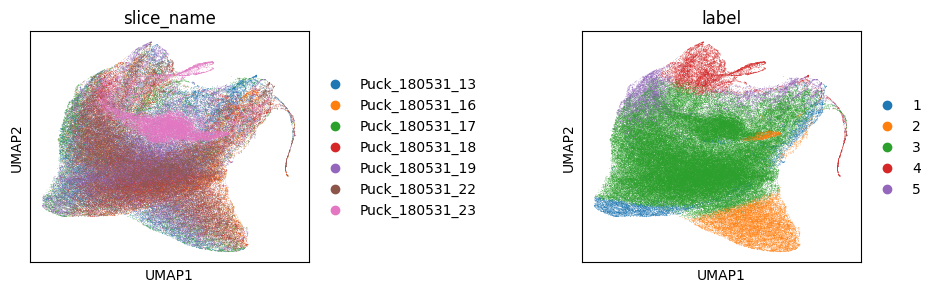

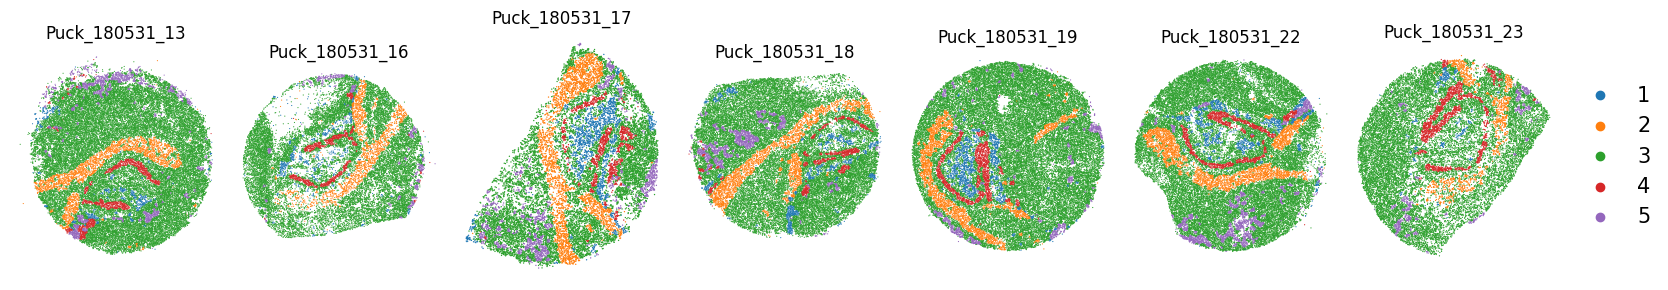

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (3, 3)
plt.rcParams['font.size'] = 10

sc.pl.umap(adata_concat, color=['slice_name', 'label'], ncols=2, wspace=0.8, show=True)

for it in range(len(section_ids)):
    Batch_list[it].obs['label'] = adata_concat[adata_concat.obs['slice_name'] == section_ids[it]].obs['label'].values

spot_size = 30
fig, ax = plt.subplots(1, 7, figsize=(20, 5), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})
for it in range(len(section_ids)):
    if it == 6:
        _sc_0 = sc.pl.spatial(Batch_list[it], img_key=None, color=['label'], title=[section_ids[it]],
                              legend_fontsize=15, show=False, ax=ax[it], frameon=False, spot_size=spot_size)
    else:
        _sc_0 = sc.pl.spatial(Batch_list[it], img_key=None, color=['label'], title=[section_ids[it]],
                              legend_loc=None, show=False, ax=ax[it], frameon=False, spot_size=spot_size)
plt.show()

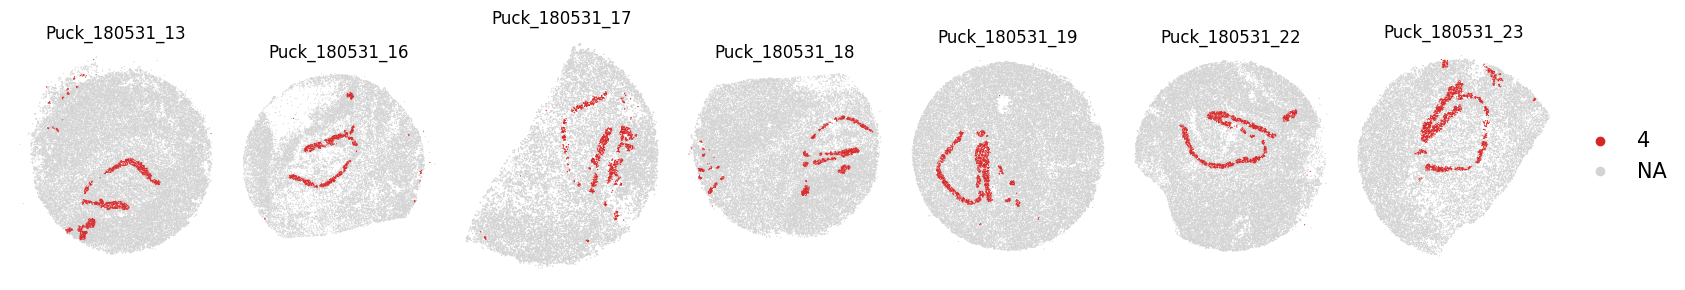


🚀 Starting ICP Alignment based on landmark domain...
Aligning Puck_180531_13 to Puck_180531_23...
Aligning Puck_180531_16 to Puck_180531_23...
Aligning Puck_180531_17 to Puck_180531_23...
Aligning Puck_180531_18 to Puck_180531_23...
Aligning Puck_180531_19 to Puck_180531_23...
Aligning Puck_180531_22 to Puck_180531_23...


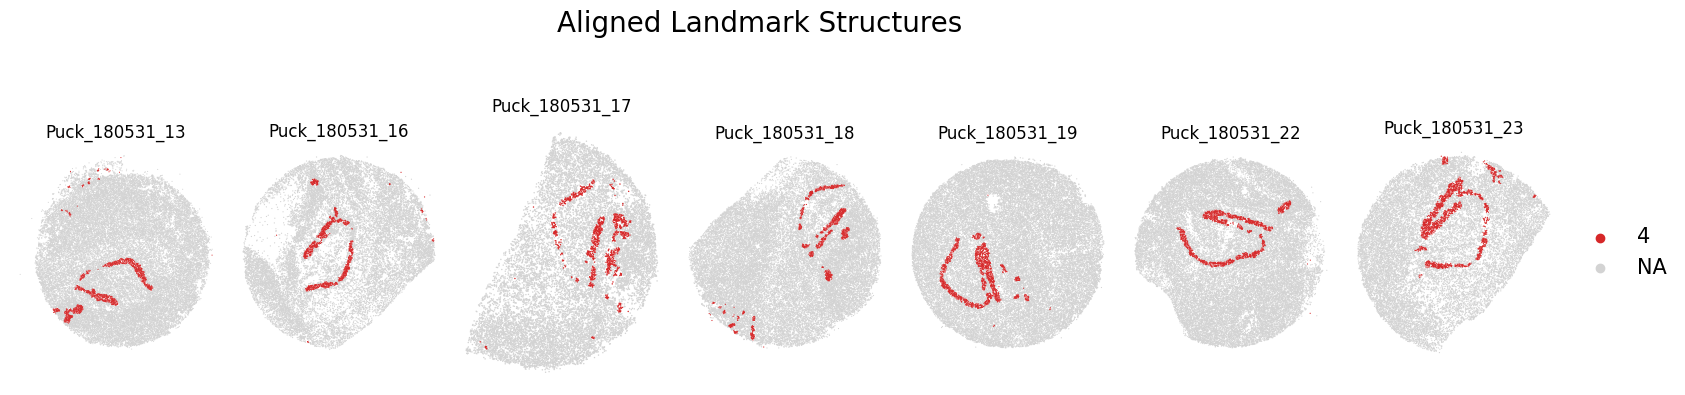

In [ ]:

landmark_domain = '4'

fig, ax = plt.subplots(1, 7, figsize=(20, 5), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})
for it in range(len(section_ids)):
    if it == 6:
        _sc_0 = sc.pl.spatial(Batch_list[it], img_key=None, color=['label'], title=[section_ids[it]],
                              legend_fontsize=15, show=False, ax=ax[it], frameon=False, spot_size=spot_size, groups=[landmark_domain])
    else:
        _sc_0 = sc.pl.spatial(Batch_list[it], img_key=None, color=['label'], title=[section_ids[it]],
                              legend_loc=None, show=False, ax=ax[it], frameon=False, spot_size=spot_size, groups=[landmark_domain])
plt.show()

print("\n🚀 Starting ICP Alignment based on landmark domain...")
iter_comb = [(0,6), (1,6), (2,6), (3,6), (4,6), (5,6)]

for comb in iter_comb:
    i, j = comb[0], comb[1]
    adata_target = Batch_list[i]
    adata_ref = Batch_list[j]

    print(f"Aligning {section_ids[i]} to {section_ids[j]}...")

    loc_target = adata_target[adata_target.obs['label'] == landmark_domain].obsm['spatial'].copy()
    loc_ref = adata_ref[adata_ref.obs['label'] == landmark_domain].obsm['spatial'].copy()

    T, distances, _ = TOOLS.icp(loc_target, loc_ref, tolerance=0.001)
    aligned_coor = TOOLS.transform(adata_target.obsm['spatial'].copy(), T)

    adata_target.obsm["spatial_aligned"] = aligned_coor

Batch_list[6].obsm["spatial_aligned"] = Batch_list[6].obsm["spatial"].copy()

fig, ax = plt.subplots(1, 7, figsize=(20, 5), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})
for it in range(len(section_ids)):

    temp_coor = Batch_list[it].obsm['spatial'].copy()
    Batch_list[it].obsm['spatial'] = Batch_list[it].obsm['spatial_aligned'].copy()

    if it == 6:
        _sc_0 = sc.pl.spatial(Batch_list[it], img_key=None, color=['label'], title=[section_ids[it]],
                              legend_fontsize=15, show=False, ax=ax[it], frameon=False, spot_size=spot_size, groups=[landmark_domain])
    else:
        _sc_0 = sc.pl.spatial(Batch_list[it], img_key=None, color=['label'], title=[section_ids[it]],
                              legend_loc=None, show=False, ax=ax[it], frameon=False, spot_size=spot_size, groups=[landmark_domain])


    Batch_list[it].obsm['spatial'] = temp_coor

plt.suptitle("Aligned Landmark Structures", fontsize=20)
plt.show()

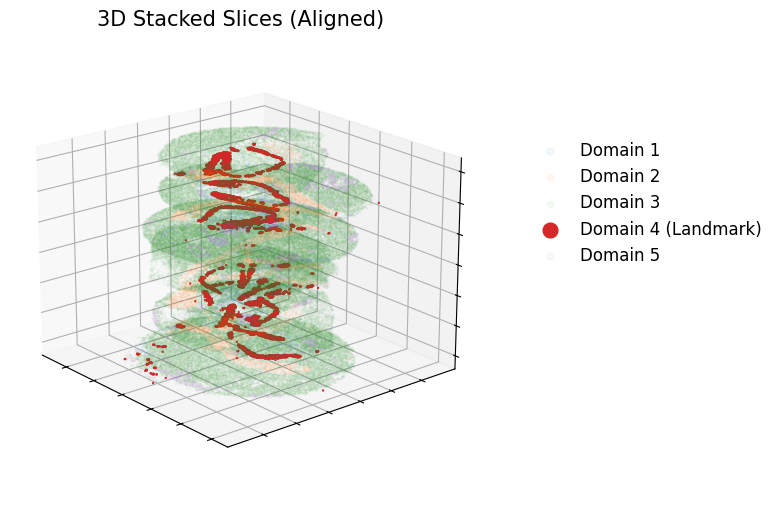

In [ ]:

adata_concat.obs['Z'] = list(Batch_list[0].shape[0] * [0]) + list(Batch_list[1].shape[0] * [10]) \
                      + list(Batch_list[2].shape[0] * [20]) + list(Batch_list[3].shape[0] * [30]) \
                      + list(Batch_list[4].shape[0] * [40]) + list(Batch_list[5].shape[0] * [50]) \
                      + list(Batch_list[6].shape[0] * [60])


All_coor = adata_concat.obs[['Z']].copy()
All_coor['X'] = 0.0
All_coor['Y'] = 0.0

for i, section in enumerate(section_ids):
    All_coor.loc[adata_concat.obs['slice_name'] == section, ['X', 'Y']] = Batch_list[i].obsm["spatial_aligned"]

fig = plt.figure(figsize=(10, 6))
ax1 = plt.axes(projection='3d')


color_dict = dict(zip(adata_concat.obs['label'].cat.categories, adata_concat.uns['label_colors']))

for label in np.unique(adata_concat.obs['label']):
    temp_Coor = All_coor.loc[adata_concat.obs['label'] == label, :]
    temp_xd = temp_Coor['X']
    temp_yd = temp_Coor['Y']
    temp_zd = temp_Coor['Z']

    if label == landmark_domain:
        ax1.scatter3D(temp_xd, temp_yd, temp_zd, c=color_dict[label],
                      s=0.5, marker="o", label=f"Domain {label} (Landmark)", alpha=1)
    else:

        ax1.scatter3D(temp_xd, temp_yd, temp_zd, c=color_dict[label],
                      s=0.1, marker="o", label=f"Domain {label}", alpha=0.05)


plt.legend(bbox_to_anchor=(1.1, 0.8), markerscale=15, frameon=False, fontsize=12)
plt.title('3D Stacked Slices (Aligned)', fontsize=15)
ax1.elev = 20
ax1.azim = -40


ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_zlabel('')
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_zticklabels([])
ax1.grid(True)

plt.show()